# Dynamic Pricing & Discount Strategy Analysis

Analyzing markdown timing, price elasticity by category, and brand pricing power
using a retail dataset, to produce a data-backed discount strategy recommendation.

**Dataset:** [Retail Markdown Optimization: Discounts & Sales](https://www.kaggle.com/datasets/arbaaztamboli/retail-markdown-optimization-discounts-and-sales)

## 1. Load and Explore the Data

Loading the dataset and checking its structure, shape, column names, and data types,
before doing any analysis.

In [23]:
import pandas as pd

df = pd.read_csv('SYNTHETIC Markdown Dataset.csv')
df.head()

,Product_ID,Category,Brand,Season,Product_Name,Original_Price,Competitor_Price,Seasonality_Factor,Markdown_1,Markdown_2,...,Historical_Sales,Sales_After_M1,Sales_After_M2,Sales_After_M3,Sales_After_M4,Stock_Level,Promotion_Type,Customer Ratings,Return Rate,Optimal Discount
0,1,Skincare,BrandA,Summer,Sunscreen,70.39,70.98,1.71,0.31,0.49,...,344,404,540,650,979,183,In-Store,4.9,1.97,0.36
1,2,Skincare,BrandB,Rainy,Eye Cream,55.35,56.58,0.85,0.39,0.21,...,98,107,116,118,143,142,Online,4.0,2.57,0.29
2,3,Skincare,BrandA,Spring,Face Mist,26.16,28.54,1.03,0.17,0.43,...,72,72,87,84,84,112,Social Media,2.3,4.64,0.33
3,4,Bodycare,BrandD,Winter,Shower Gel,99.34,98.57,1.91,0.20,0.21,...,243,281,316,361,539,57,In-Store,4.9,1.42,0.25
4,5,Skincare,BrandA,Winter,Peeling Gel,60.33,61.05,1.65,0.14,0.20,...,251,289,325,402,534,125,In-Store,4.6,1.36,0.23


In [24]:
df.shape

(43750, 22)

In [25]:
df.columns.tolist()

['Product_ID',
 'Category',
 'Brand',
 'Season',
 'Product_Name',
 'Original_Price',
 'Competitor_Price',
 'Seasonality_Factor',
 'Markdown_1',
 'Markdown_2',
 'Markdown_3',
 'Markdown_4',
 'Historical_Sales',
 'Sales_After_M1',
 'Sales_After_M2',
 'Sales_After_M3',
 'Sales_After_M4',
 'Stock_Level',
 'Promotion_Type',
 'Customer Ratings',
 'Return Rate',
 'Optimal Discount']

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43750 entries, 0 to 43749
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Product_ID          43750 non-null  int64  
 1   Category            43750 non-null  object 
 2   Brand               43750 non-null  object 
 3   Season              43750 non-null  object 
 4   Product_Name        43750 non-null  object 
 5   Original_Price      43750 non-null  float64
 6   Competitor_Price    43750 non-null  float64
 7   Seasonality_Factor  43750 non-null  float64
 8   Markdown_1          43750 non-null  float64
 9   Markdown_2          43750 non-null  float64
 10  Markdown_3          43750 non-null  float64
 11  Markdown_4          43750 non-null  float64
 12  Historical_Sales    43750 non-null  int64  
 13  Sales_After_M1      43750 non-null  int64  
 14  Sales_After_M2      43750 non-null  int64  
 15  Sales_After_M3      43750 non-null  int64  
 16  Sale

In [27]:
df.describe()

,Product_ID,Original_Price,Competitor_Price,Seasonality_Factor,Markdown_1,Markdown_2,Markdown_3,Markdown_4,Historical_Sales,Sales_After_M1,Sales_After_M2,Sales_After_M3,Sales_After_M4,Stock_Level,Customer Ratings,Return Rate,Optimal Discount
count,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000,43750.000000
mean,21705.645051,52.659917,53.648610,1.328372,0.250620,0.350107,0.199834,0.400097,171.893554,201.142171,250.353897,286.513623,370.565303,124.854469,4.290862,2.203713,0.300373
std,12526.600860,27.515733,27.542159,0.466122,0.086428,0.086604,0.057907,0.057977,88.500750,111.765796,152.876420,184.139572,258.253190,43.211560,0.810869,1.258030,0.036854
min,1.000000,5.000000,4.100000,0.500000,0.100000,0.200000,0.100000,0.300000,26.000000,26.000000,25.000000,26.000000,25.000000,50.000000,2.000000,1.000000,0.180000
25%,10863.250000,28.820000,29.800000,0.900000,0.180000,0.280000,0.150000,0.350000,101.000000,113.000000,128.000000,137.000000,152.000000,88.000000,4.000000,1.360000,0.280000
50%,21705.500000,52.840000,53.835000,1.500000,0.250000,0.350000,0.200000,0.400000,154.000000,175.000000,210.000000,236.000000,299.000000,124.000000,4.600000,1.720000,0.300000
75%,32550.750000,76.630000,77.597500,1.750000,0.330000,0.430000,0.250000,0.450000,233.000000,276.000000,357.000000,415.000000,555.000000,162.000000,4.800000,2.600000,0.320000
max,43400.000000,100.000000,102.960000,2.000000,0.400000,0.500000,0.300000,0.500000,416.000000,579.000000,844.000000,1114.000000,1535.000000,200.000000,5.000000,6.000000,0.420000


## 2. Understand the Columns

Checking unique values across key categorical columns (Category, Season, Promotion Type,
Brand) to understand what we're working with.

In [28]:
df['Category'].unique()

array(['Skincare', 'Bodycare', 'Makeup'], dtype=object)

In [29]:
df['Season'].unique()

array(['Summer', 'Rainy', 'Spring', 'Winter'], dtype=object)

In [30]:
df['Promotion_Type'].unique()

array(['In-Store', 'Online', 'Social Media'], dtype=object)

In [31]:
df['Brand'].unique()

array(['BrandA', 'BrandB', 'BrandD', 'BrandE', 'BrandF', 'BrandC'],
      dtype=object)

In [32]:
df[['Original_Price', 'Markdown_1', 'Markdown_2', 'Markdown_3', 'Markdown_4']].head()

,Original_Price,Markdown_1,Markdown_2,Markdown_3,Markdown_4
0,70.39,0.31,0.49,0.18,0.48
1,55.35,0.39,0.21,0.10,0.46
2,26.16,0.17,0.43,0.30,0.43
3,99.34,0.20,0.21,0.13,0.47
4,60.33,0.14,0.20,0.21,0.36


## 3. Calculate Discount Percentage

The `Markdown_1` through `Markdown_4` columns represent discount rates as decimals
which is confirmed by comparing them against `Original_Price`.
Converting these to percentage form for readability.

In [33]:
for i in range(1,5):
  df[f'Discount_Pct_M{i}'] = df[f'Markdown_{i}'] * 100

## 4. Calculate Sales Lift Percentage

Measuring how much sales changed after each markdown, relative to `Historical_Sales`
which is the baseline before any discount was applied.

In [34]:
for i in range(1, 5):
    df[f'Sales_Lift_Pct_M{i}'] = (df[f'Sales_After_M{i}'] - df['Historical_Sales']) / df['Historical_Sales'] * 100

df[['Original_Price','Markdown_1','Discount_Pct_M1', 'Sales_Lift_Pct_M1','Markdown_2','Discount_Pct_M2', 'Sales_Lift_Pct_M2' ]].head()

,Original_Price,Markdown_1,Discount_Pct_M1,Sales_Lift_Pct_M1,Markdown_2,Discount_Pct_M2,Sales_Lift_Pct_M2
0,70.39,0.31,31.0,17.441860,0.49,49.0,56.976744
1,55.35,0.39,39.0,9.183673,0.21,21.0,18.367347
2,26.16,0.17,17.0,0.000000,0.43,43.0,20.833333
3,99.34,0.20,20.0,15.637860,0.21,21.0,30.041152
4,60.33,0.14,14.0,15.139442,0.20,20.0,29.482072


## 5. Calculate Price Elasticity

Price elasticity = % change in sales ÷ % change in price (discount).

- Elasticity > 1: highly responsive to discounting
- Elasticity ≈ 1: sales move proportionally with the discount
- Elasticity < 1: inelastic, customers barely respond to price cuts

The price elasticity is calculated per markdown level, then averaged across all four markdown levels for a robust elasticity score per product.

In [35]:
for i in range(1,5):
  df[f'Elasticity_M{i}'] = df[f'Sales_Lift_Pct_M{i}'] / df[f'Discount_Pct_M{i}']

In [36]:
elasticity_cols = [f'Elasticity_M{i}' for i in range(1, 5)]
df.groupby('Category')[elasticity_cols].mean()

,Elasticity_M1,Elasticity_M2,Elasticity_M3,Elasticity_M4
Category,,,,
Bodycare,0.672067,1.324176,3.534442,2.901442
Makeup,0.679193,1.331692,3.558382,2.922707
Skincare,0.501579,0.979193,2.594634,2.108361


In [37]:
df[['Discount_Pct_M1', 'Discount_Pct_M2', 'Discount_Pct_M3', 'Discount_Pct_M4']].mean()

,0
Discount_Pct_M1,25.062034
Discount_Pct_M2,35.010720
Discount_Pct_M3,19.983383
Discount_Pct_M4,40.009691


In [38]:
season_elasticity = df.groupby('Season')[['Elasticity_M1', 'Elasticity_M2','Elasticity_M3', 'Elasticity_M4' ]].mean()
season_elasticity

,Elasticity_M1,Elasticity_M2,Elasticity_M3,Elasticity_M4
Season,,,,
Rainy,0.361164,0.691029,1.801114,1.452667
Spring,0.328458,0.634297,1.653282,1.314199
Summer,0.849879,1.684899,4.512689,3.724890
Winter,0.852634,1.680260,4.522605,3.724387


## 6. Elasticity by Category and Season

Checking whether discount effectiveness varies by season, and whether that pattern
holds consistently across all four markdown levels.

Finding: each category has a specific season where discounting is notably
weak. Bodycare in Spring, Makeup in Rainy season, Skincare in both Rainy and Spring.
This pattern was consistent across all four markdown levels.

In [39]:
for i in range(1, 5):
    print(f"Markdown {i}")
    print()
    print(df.groupby(['Category', 'Season'])[f'Elasticity_M{i}'].mean().unstack())
    print()

Markdown 1

Season       Rainy    Spring    Summer    Winter
Category                                        
Bodycare  0.847656  0.144377  0.850598  0.855139
Makeup    0.155731  0.851707  0.844578  0.848155
Skincare  0.151998  0.145910  0.852345  0.853375

Markdown 2

Season       Rainy    Spring    Summer    Winter
Category                                        
Bodycare  1.674157  0.267506  1.690414  1.683810
Makeup    0.272813  1.682964  1.665324  1.671929
Skincare  0.269991  0.266991  1.692114  1.682379

Markdown 3

Season       Rainy    Spring    Summer    Winter
Category                                        
Bodycare  4.447704  0.661754  4.513170  4.566213
Makeup    0.662366  4.496637  4.498945  4.484500
Skincare  0.674647  0.655331  4.519997  4.513999

Markdown 4

Season       Rainy    Spring    Summer    Winter
Category                                        
Bodycare  3.714460  0.483571  3.724253  3.727281
Makeup    0.482248  3.694361  3.699213  3.739979
Skincare  0.488489

## 7. Brand Pricing Power

Checking whether certain brands sell well without needing discounts, by comparing
average elasticity, customer rating, and pricing versus competitors across brands.

Finding: all six brands performed nearly identically across every metric, meaning
brand was not a meaningful differentiator in this dataset.

In [40]:
df['Avg_Elasticity'] = df[['Elasticity_M1', 'Elasticity_M2','Elasticity_M3','Elasticity_M4']].mean(axis=1)

brand_summary = df.groupby('Brand').agg(
    avg_elasticity = ('Avg_Elasticity','mean'),
    avg_rating = ('Customer Ratings', 'mean'),
    avg_price = ('Original_Price', 'mean'),
    avg_competitor_price = ('Competitor_Price', 'mean')
).sort_values('avg_elasticity')

brand_summary

,avg_elasticity,avg_rating,avg_price,avg_competitor_price
Brand,,,,
BrandC,1.844593,4.278976,52.135902,53.118513
BrandE,1.853885,4.295747,52.917723,53.903954
BrandB,1.858373,4.293404,52.718094,53.717297
BrandF,1.861811,4.284056,52.894875,53.885317
BrandA,1.862317,4.288913,52.317827,53.305750
BrandD,1.872533,4.304327,52.988079,53.973966


## 8. Visualizations

Three charts summarizing the key findings above.

### Elasticity by Category

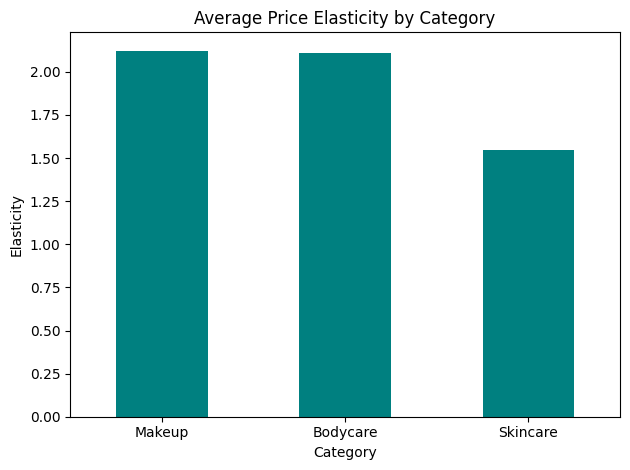

In [41]:
import matplotlib.pyplot as plt

df.groupby('Category')['Avg_Elasticity'].mean().sort_values(ascending=False).plot(kind='bar', color='teal')
plt.title('Average Price Elasticity by Category')
plt.ylabel('Elasticity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Elasticity by Category and Season
The strongest and most consistent finding. Each category's weak response season
is clearly visible here.

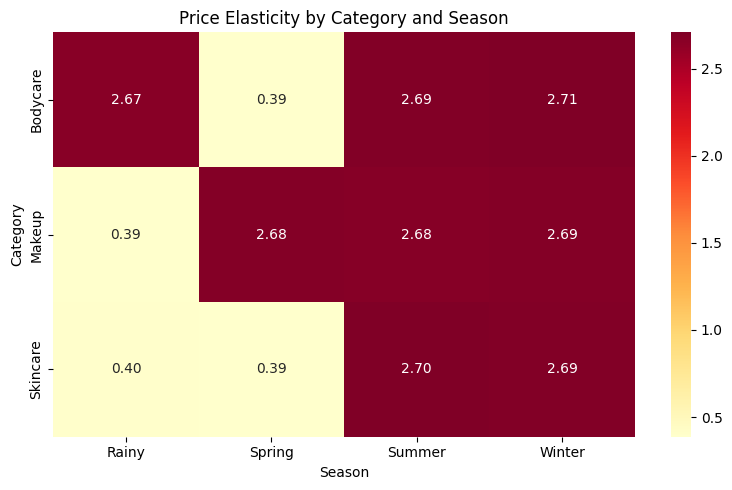

In [42]:
import seaborn as sns

pivot = df.groupby(['Category', 'Season'])['Avg_Elasticity'].mean().unstack()
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Price Elasticity by Category and Season')
plt.tight_layout()
plt.show()

### Discount % vs Sales Lift %

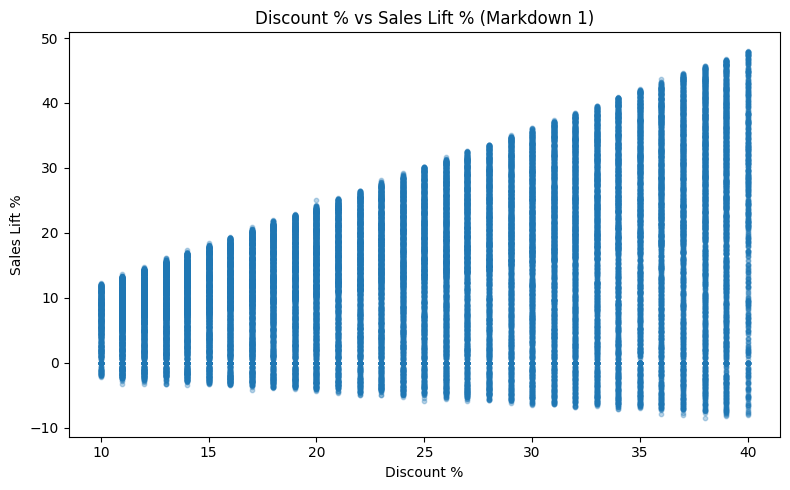

In [43]:
plt.figure(figsize=(8,5))
plt.scatter(df['Discount_Pct_M1'], df['Sales_Lift_Pct_M1'], alpha=0.3, s=10)
plt.xlabel('Discount %')
plt.ylabel('Sales Lift %')
plt.title('Discount % vs Sales Lift % (Markdown 1)')
plt.tight_layout()
plt.show()

## 9. Key Findings & Recommendation

Findings:
1. All categories show inelastic to moderate price sensitivity overall.
2. Season matters more than category alone. Each category has a
   season where discounting barely moves sales.
3. Brand is not a meaningful differentiator in elasticity, rating, or pricing.
4. Discount depth and sales lift are strongly, near linearly related overall.

Recommendation:

Skincare and Bodycare markdowns should be timed around their effective seasons
rather than applied uniformly. Avoid discounting Skincare during Rainy and Spring,
and Bodycare during Spring since both show minimal sales response in these windows.
Concentrate markdown budget on Summer and Winter, where elasticity is 3–5x stronger.
Since brand does not meaningfully affect price sensitivity, pricing strategy should
be driven by category and season and not brand identity.

## References


- Tamboli, A. (2024). *Retail Markdown Optimization: Discounts & Sales* [Data set]. Kaggle. https://www.kaggle.com/datasets/arbaaztamboli/retail-markdown-optimization-discounts-and-sales


- McKinney, W. *pandas: Powerful Python Data Analysis Toolkit*. https://pandas.pydata.org/
- Hunter, J.D. *Matplotlib: A 2D Graphics Environment*. https://matplotlib.org/
- Waskom, M. *seaborn: Statistical Data Visualization*. https://seaborn.pydata.org/


- Price elasticity of demand — standard economics concept measuring the responsiveness
  of quantity demanded to a change in price. https://www.investopedia.com/terms/p/priceelasticity.asp

- W3Schools. *Python Pandas Tutorial*. https://www.w3schools.com/python/pandas/default.asp
- W3Schools. *Data Science Tutorial*. https://www.w3schools.com/datascience/
- W3Schools. *Matplotlib Tutorial*. https://www.w3schools.com/python/matplotlib_intro.asp
- W3Schools. *Python Machine Learning Tutorial*. https://www.w3schools.com/python/python_ml_getting_started.asp
- Ying, K. (2022). *Machine Learning for Everybody – Full Course*. freeCodeCamp.org. https://www.youtube.com/watch?v=i_LwzRVP7bg